# Short-event-bar alpha workbench

This notebook is the manual companion to the systematic 200/500/1,000-event screen. It is designed to answer four questions visually:

1. What exactly is the selected feature?
2. Is its relationship with future return monotonic rather than driven by one tail?
3. Does it repeat across bar sizes, sides, months and chronological periods?
4. Is the relationship sufficiently clear to justify defining a trading rule?

It does not calculate strategy profitability. Entry, exit, overlapping positions and costs are deliberately deferred until a signal rule has been frozen.

## Current screen result

The clearest cross-scale result is mean reversion after a prior trend that points in the same direction as the current bar imbalance. The default feature measures the price trend over the 12,000 events before the current bar, aligns it with the current imbalance side, and excludes the current bar itself.

The fitted impact residual was not a leading feature. Sell-side normalized impact, flow persistence, normalized range and relative flow rate were more repeatable and remain available in the control cell.

In [1]:
from pathlib import Path
from datetime import datetime, timezone
import math
import os
import sys

os.environ.setdefault('MPLCONFIGDIR', '/tmp/alpha-search-matplotlib')
Path(os.environ['MPLCONFIGDIR']).mkdir(parents=True, exist_ok=True)

import matplotlib.pyplot as plt
import numpy as np
import polars as pl
from IPython.display import Markdown, display
get_ipython().run_line_magic('matplotlib', 'inline')

REPO = Path('/Users/petermillington/Research/market-impact-research')
ALPHA = REPO / 'alpha-search'
SHARED = REPO / 'shared-data'
sys.path.insert(0, str(ALPHA / 'src'))

from alpha_search.impact_model import add_asymmetric_impact_features, fit_asymmetric_log_impact
from alpha_search.screen_features import screen_feature_catalog

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams.update({'figure.dpi': 110, 'axes.spines.top': False, 'axes.spines.right': False})
BUY_COLOUR, SELL_COLOUR = '#13795b', '#c2413b'
PERIOD_COLOURS = {'train': '#64748b', 'validation': '#2563eb', 'later sandbox': '#d97706'}

## Manual controls

In [2]:
BAR_SIZE = 200                 # 200, 500 or 1_000
FUTURE_EVENT_COUNT = 12_000    # 12_000 or 16_000
FEATURE = 'aligned_pretrend_12000_events'
SECOND_FEATURE = 'normalised_signed_impact'
HEATMAP_SIDE = -1              # -1 sell-dominated, +1 buy-dominated
N_QUANTILES = 5
N_SMOOTH_BINS = 10

TRAIN_END = '2020-09-01'
VALIDATION_END = '2021-07-01'

assert BAR_SIZE in {200, 500, 1_000}
assert FUTURE_EVENT_COUNT in {12_000, 16_000}
catalog = dict(screen_feature_catalog())
assert FEATURE in catalog and SECOND_FEATURE in catalog

## Feature catalogue

In [3]:
definitions = {
    'log_abs_signed_imbalance': 'log absolute signed BTC imbalance in the current bar',
    'absolute_imbalance_ratio': '|signed BTC imbalance| / current bar gross volume',
    'normalised_imbalance': '|signed BTC imbalance| / preceding 24h gross volume',
    'log_gross_volume': 'log current-bar BTC volume',
    'bar_volume_fraction_24h': 'current-bar BTC volume / preceding 24h gross volume',
    'log_duration': 'log seconds required to complete the event bar',
    'relative_flow_rate': 'current BTC/second divided by preceding-24h average BTC/second',
    'normalised_range': 'current high-low range / preceding-24h realised volatility',
    'log_trailing_volatility': 'log preceding-24h realised volatility',
    'return_efficiency': 'current return aligned with imbalance / current high-low range',
    'normalised_signed_impact': 'current return aligned with imbalance / preceding-24h volatility',
    'fills_per_event': 'original exchange fills / reconstructed events',
    'price_levels_per_event': 'summed event price-level counts / reconstructed events',
    'abs_event_sign_imbalance': '|buy event count - sell event count| / event count',
    'aligned_pretrend_1000_events': 'strictly prior 1,000-event return aligned with current imbalance',
    'aligned_pretrend_4000_events': 'strictly prior 4,000-event return aligned with current imbalance',
    'aligned_pretrend_12000_events': 'strictly prior 12,000-event return aligned with current imbalance',
    'aligned_flow_persistence_1000_events': 'strictly prior 1,000-event signed flow aligned with current side',
    'aligned_flow_persistence_4000_events': 'strictly prior 4,000-event signed flow aligned with current side',
    'aligned_flow_persistence_12000_events': 'strictly prior 12,000-event signed flow aligned with current side',
    'expected_normalised_impact': 'training-fitted side-specific expected normalized impact',
    'impact_residual': 'observed minus training-fitted normalized impact',
    'marginal_impact_bps_per_btc': 'derivative of the fitted impact curve in bps per extra BTC',
}
feature_table = pl.DataFrame([
    {'feature': name, 'family': family, 'definition': definitions[name]}
    for name, family in screen_feature_catalog()
])
display(feature_table)
display(Markdown(f"**Selected:** {FEATURE} — {definitions[FEATURE]}"))

feature,family,definition
str,str,str
"""log_abs_signed_imbalance""","""imbalance""","""log absolute signed BTC imbala…"
"""absolute_imbalance_ratio""","""imbalance""","""|signed BTC imbalance| / curre…"
"""normalised_imbalance""","""imbalance""","""|signed BTC imbalance| / prece…"
"""log_gross_volume""","""volume""","""log current-bar BTC volume"""
"""bar_volume_fraction_24h""","""volume""","""current-bar BTC volume / prece…"
…,…,…
"""aligned_pretrend_12000_events""","""pretrend""","""strictly prior 12,000-event re…"
"""aligned_flow_persistence_12000…","""flow_persistence""","""strictly prior 12,000-event si…"
"""expected_normalised_impact""","""fitted_impact""","""training-fitted side-specific …"


**Selected:** aligned_pretrend_12000_events — strictly prior 12,000-event return aligned with current imbalance

## Cross-scale ranking from the systematic screen

feature,feature_family,side,future_event_count,cells,bar_sizes,each_bar_size_stable,validation_signs,later_signs,validation_median_spread_bps,later_median_spread_bps,worst_cell_absolute_spread_bps,minimum_validation_abs_day_t,minimum_later_abs_day_t,maximum_validation_fdr_q,minimum_validation_month_share,minimum_later_month_share,cross_scale_qualified
str,str,str,i64,i64,i64,bool,i64,i64,f64,f64,f64,f64,f64,f64,f64,f64,bool
"""aligned_pretrend_12000_events""","""pretrend""","""sell""",16000,3,3,true,1,1,-9.325051,-8.592371,8.374878,8.346477,6.982757,8.5518e-16,0.9,0.666667,true
"""aligned_pretrend_12000_events""","""pretrend""","""sell""",12000,3,3,true,1,1,-8.2274,-7.48857,7.283612,8.661336,7.14956,6.6869e-17,0.9,0.833333,true
"""aligned_pretrend_12000_events""","""pretrend""","""buy""",16000,3,3,true,1,1,-6.99483,-6.593159,6.277872,6.193702,4.681592,2.7219e-9,0.8,0.666667,true
"""aligned_pretrend_12000_events""","""pretrend""","""buy""",12000,3,3,true,1,1,-6.050458,-6.140365,5.744817,6.313145,5.043054,1.3619e-9,0.8,0.666667,true
"""normalised_range""","""volatility""","""sell""",16000,3,3,true,1,1,-10.020119,-5.513963,5.040685,4.040932,2.246891,0.000138,0.8,0.833333,true
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
"""aligned_flow_persistence_12000…","""flow_persistence""","""buy""",12000,3,3,true,1,1,-3.365877,-2.334487,2.155208,3.989705,4.602745,0.000162,0.7,0.833333,true
"""aligned_flow_persistence_4000_…","""flow_persistence""","""buy""",16000,3,3,true,1,1,-3.215648,-2.472612,2.131271,4.060643,5.524817,0.000129,0.6,0.833333,true
"""log_abs_signed_imbalance""","""imbalance""","""sell""",16000,3,3,true,1,1,-4.836044,-2.499792,2.086717,6.749403,3.919239,8.1650e-11,0.8,0.666667,true


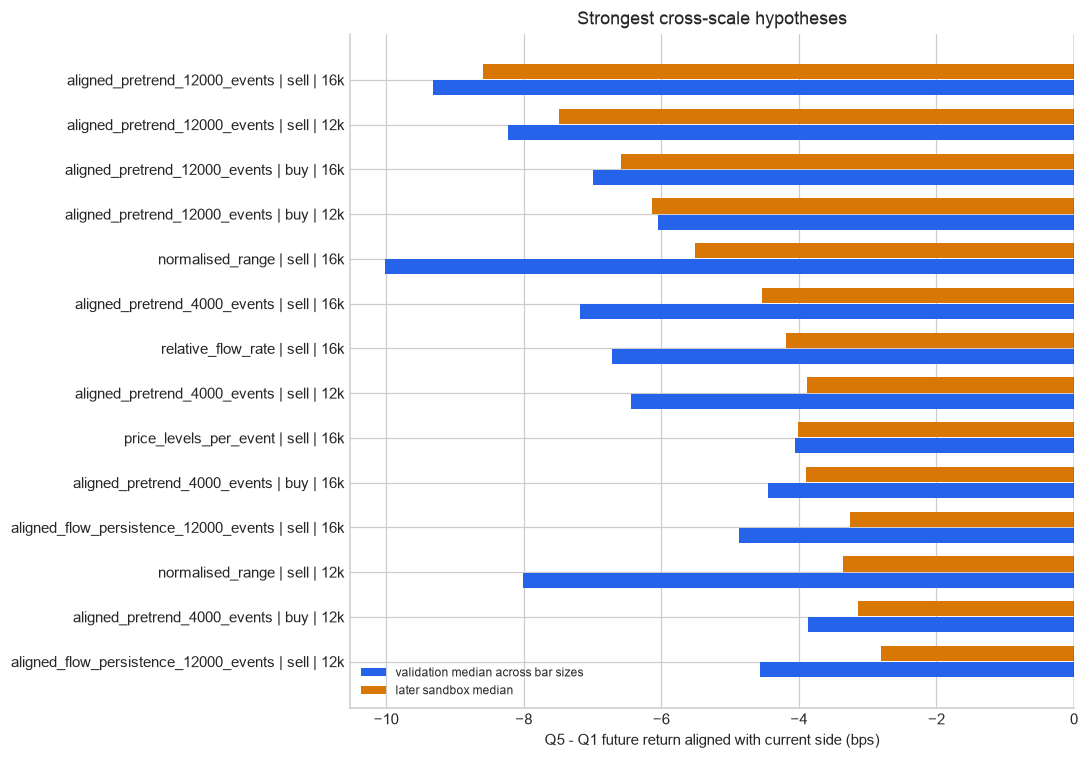

In [4]:
REPORT_ROOT = ALPHA / 'reports' / 'short_event_screen_v1'
cross_scale = pl.read_csv(REPORT_ROOT / 'cross_scale_ranking.csv')
qualified = cross_scale.filter(pl.col('cross_scale_qualified'))
display(qualified.head(25))

top = qualified.head(14).sort('worst_cell_absolute_spread_bps')
labels = [f"{r['feature']} | {r['side']} | {r['future_event_count']//1000}k"
          for r in top.iter_rows(named=True)]
fig, ax = plt.subplots(figsize=(10, 7))
y = np.arange(top.height)
ax.barh(y - .18, top['validation_median_spread_bps'].to_numpy(), height=.34,
        color=PERIOD_COLOURS['validation'], label='validation median across bar sizes')
ax.barh(y + .18, top['later_median_spread_bps'].to_numpy(), height=.34,
        color=PERIOD_COLOURS['later sandbox'], label='later sandbox median')
ax.axvline(0, color='black', lw=.8)
ax.set_yticks(y, labels)
ax.set_xlabel('Q5 - Q1 future return aligned with current side (bps)')
ax.set_title('Strongest cross-scale hypotheses')
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

## Load the selected bar size and recreate fitted-impact features

The impact curve is fitted on training only. This is needed only when the selected feature is expected impact, residual or marginal impact, but the columns are recreated for all choices so features can be changed without modifying later cells.

In [5]:
def utc_ms(value):
    return int(datetime.strptime(value, '%Y-%m-%d').replace(tzinfo=timezone.utc).timestamp() * 1_000)

TRAIN_END_MS = utc_ms(TRAIN_END)
VALIDATION_END_MS = utc_ms(VALIDATION_END)
CACHE_ROOT = SHARED / 'features' / 'alpha' / 'symbol=BTCUSDT' / 'short_event_screen_v1'
cache_path = CACHE_ROOT / f'event_{BAR_SIZE}' / 'part-000.parquet'
base = pl.scan_parquet(cache_path)
first_ms = int(base.select(pl.col('end_time_ms').min()).collect().item())
base = base.filter(pl.col('end_time_ms') >= first_ms + 86_400_000)

impact_fit = fit_asymmetric_log_impact(base.filter(pl.col('end_time_ms') < TRAIN_END_MS))
enriched = add_asymmetric_impact_features(base, impact_fit)

horizon_lookup = {
    200: {12_000: 60, 16_000: 80},
    500: {12_000: 24, 16_000: 32},
    1_000: {12_000: 12, 16_000: 16},
}
HORIZON = horizon_lookup[BAR_SIZE][FUTURE_EVENT_COUNT]
TARGET = f'future_return_{HORIZON}_bps'
ELAPSED = f'future_elapsed_{HORIZON}_minutes'

frame = enriched.select(
    'end_time_ms', 'signed_imbalance', FEATURE, SECOND_FEATURE, TARGET, ELAPSED
).collect().with_columns(
    pl.when(pl.col('end_time_ms') < TRAIN_END_MS).then(pl.lit('train'))
    .when(pl.col('end_time_ms') < VALIDATION_END_MS).then(pl.lit('validation'))
    .otherwise(pl.lit('later sandbox')).alias('period'),
    pl.from_epoch('end_time_ms', time_unit='ms').dt.strftime('%Y-%m').alias('month'),
    pl.col('signed_imbalance').sign().alias('side'),
    (pl.col('signed_imbalance').sign() * pl.col(TARGET)).alias('aligned_future_return_bps'),
)
print(f'event_{BAR_SIZE}, n+{HORIZON}, {frame.height:,} usable bars')
print(f'buy impact slope={impact_fit.buy.slope:.5f}; sell impact slope={impact_fit.sell.slope:.5f}')

event_200, n+60, 3,473,686 usable bars
buy impact slope=0.01908; sell impact slope=0.01890


## Data and target-duration summary

period,bars,finite_feature,elapsed_p10_minutes,elapsed_median_minutes,elapsed_p90_minutes,buy_share
str,u32,u32,f64,f64,f64,f64
"""later sandbox""",1255437,1255437,3.96985,11.838383,22.23885,0.498132
"""train""",477298,477293,12.429317,43.978067,136.314733,0.505732
"""validation""",1740951,1740951,3.36975,10.392567,30.5541,0.498818


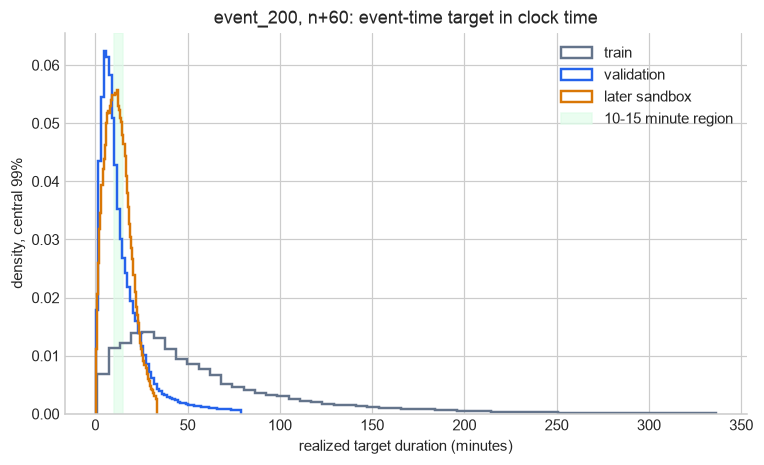

In [6]:
summary = frame.group_by('period').agg(
    pl.len().alias('bars'),
    pl.col(FEATURE).is_finite().sum().alias('finite_feature'),
    pl.col(ELAPSED).quantile(.1).alias('elapsed_p10_minutes'),
    pl.col(ELAPSED).median().alias('elapsed_median_minutes'),
    pl.col(ELAPSED).quantile(.9).alias('elapsed_p90_minutes'),
    (pl.col('side') == 1).mean().alias('buy_share'),
).sort('period')
display(summary)

fig, ax = plt.subplots(figsize=(8, 4.5))
for period in ['train', 'validation', 'later sandbox']:
    values = frame.filter(pl.col('period') == period)[ELAPSED].drop_nulls().to_numpy()
    ax.hist(values[values <= np.quantile(values, .99)], bins=55, density=True,
            histtype='step', lw=1.6, color=PERIOD_COLOURS[period], label=period)
ax.axvspan(10, 15, color='#dcfce7', alpha=.6, label='10-15 minute region')
ax.set_xlabel('realized target duration (minutes)')
ax.set_ylabel('density, central 99%')
ax.set_title(f'event_{BAR_SIZE}, n+{HORIZON}: event-time target in clock time')
ax.legend()
plt.show()

## Exact default feature

For the selected preceding-event count \(K\), let \(m=\lceil K/N\rceil\), where \(N\) is events per bar. The aligned pre-trend is

\[
z_t=\operatorname{sign}(Q_t)\,10^4
\log\left(\frac{P_{t-1}}{P_{t-m-1}}\right).
\]

It uses prices ending at the previous bar, so the current bar and every future price are excluded. A large positive value means the prior trend pointed in the same direction as the current bar imbalance. A negative Q5-minus-Q1 future aligned return therefore indicates relative mean reversion.

## Freeze training quintiles and inspect feature drift

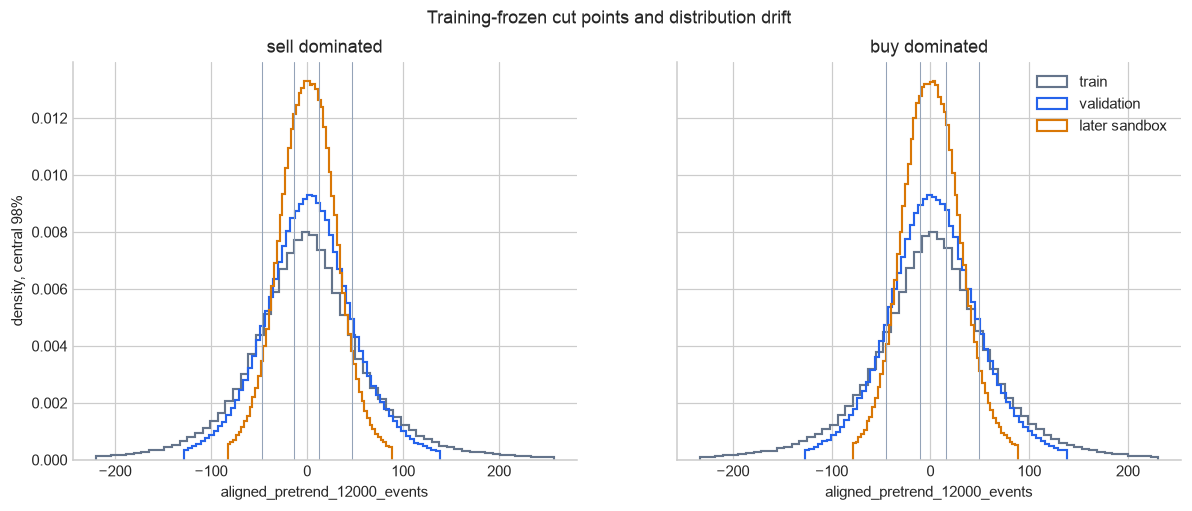

In [7]:
cuts = {}
q = np.zeros(frame.height, dtype=np.int8)
values = frame[FEATURE].to_numpy()
side = frame['side'].to_numpy().astype(np.int8)
period_values = frame['period'].to_numpy()
for side_value in (-1, 1):
    training_values = values[
        (period_values == 'train') & (side == side_value) & np.isfinite(values)
    ]
    cuts[side_value] = np.quantile(training_values, np.linspace(0, 1, N_QUANTILES + 1)[1:-1])
    chosen = (side == side_value) & np.isfinite(values)
    q[chosen] = np.digitize(values[chosen], cuts[side_value], right=True) + 1
frame = frame.with_columns(pl.Series('feature_quintile', q))

fig, axes = plt.subplots(1, 2, figsize=(13, 4.7), sharey=True)
for ax, (side_value, side_label) in zip(axes, [(-1, 'sell dominated'), (1, 'buy dominated')]):
    for period in ['train', 'validation', 'later sandbox']:
        part = frame.filter(
            (pl.col('side') == side_value) & (pl.col('period') == period) & pl.col(FEATURE).is_finite()
        )[FEATURE].to_numpy()
        lo, hi = np.quantile(part, [.01, .99])
        ax.hist(part[(part >= lo) & (part <= hi)], bins=60, density=True, histtype='step',
                lw=1.4, color=PERIOD_COLOURS[period], label=period)
    for cut in cuts[side_value]:
        ax.axvline(cut, color='#94a3b8', lw=.7)
    ax.set_xlabel(FEATURE)
    ax.set_title(side_label)
axes[0].set_ylabel('density, central 98%')
axes[1].legend()
fig.suptitle('Training-frozen cut points and distribution drift')
plt.show()

## Quintile response across all three bar sizes

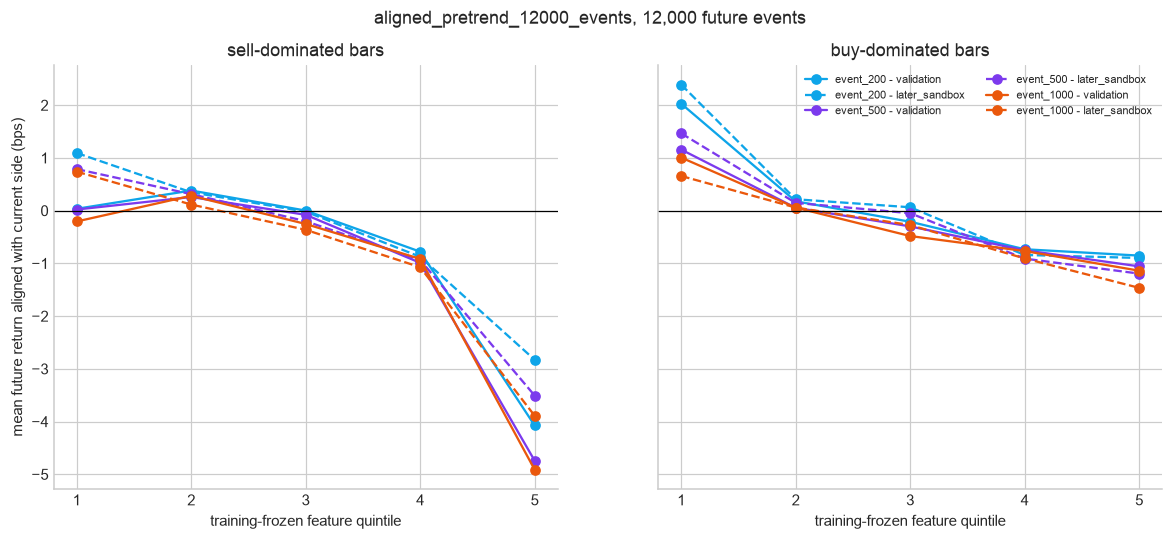

In [8]:
saved_quintiles = pl.read_csv(REPORT_ROOT / 'quintile_summary.csv').filter(
    (pl.col('feature') == FEATURE) &
    (pl.col('future_event_count') == FUTURE_EVENT_COUNT)
)
fig, axes = plt.subplots(1, 2, figsize=(13, 5), sharey=True)
for ax, side_label in zip(axes, ['sell', 'buy']):
    for construction, colour in zip(['event_200', 'event_500', 'event_1000'],
                                    ['#0ea5e9', '#7c3aed', '#ea580c']):
        for period, linestyle in [('validation', '-'), ('later_sandbox', '--')]:
            part = saved_quintiles.filter(
                (pl.col('side') == side_label) &
                (pl.col('construction') == construction) &
                (pl.col('period') == period)
            ).sort('quintile')
            ax.plot(part['quintile'].to_numpy(), part['mean_aligned_return_bps'].to_numpy(),
                    marker='o', color=colour, ls=linestyle,
                    label=f'{construction} - {period}')
    ax.axhline(0, color='black', lw=.8)
    ax.set_xticks(range(1, 6))
    ax.set_xlabel('training-frozen feature quintile')
    ax.set_title(f'{side_label}-dominated bars')
axes[0].set_ylabel('mean future return aligned with current side (bps)')
axes[1].legend(fontsize=7, ncol=2)
fig.suptitle(f'{FEATURE}, {FUTURE_EVENT_COUNT:,} future events')
plt.show()

## Smooth binned relationship for the selected construction

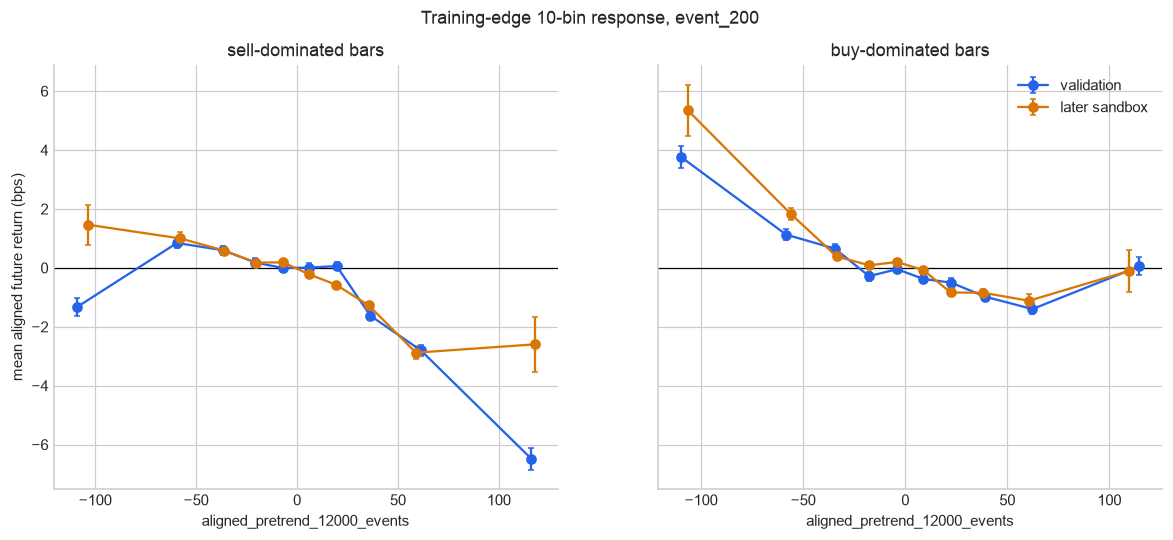

In [9]:
smooth_rows = []
for side_value, side_label in [(-1, 'sell'), (1, 'buy')]:
    train_values = frame.filter(
        (pl.col('period') == 'train') & (pl.col('side') == side_value) & pl.col(FEATURE).is_finite()
    )[FEATURE].to_numpy()
    edges = np.unique(np.quantile(train_values, np.linspace(0, 1, N_SMOOTH_BINS + 1)))
    for period in ['validation', 'later sandbox']:
        part = frame.filter(
            (pl.col('period') == period) & (pl.col('side') == side_value) &
            pl.col(FEATURE).is_finite() & pl.col('aligned_future_return_bps').is_finite()
        )
        x = part[FEATURE].to_numpy()
        y = part['aligned_future_return_bps'].to_numpy()
        ids = np.digitize(x, edges[1:-1], right=True)
        for bin_id in range(len(edges) - 1):
            chosen = ids == bin_id
            if chosen.sum() < 10:
                continue
            smooth_rows.append({
                'side': side_label, 'period': period, 'bin': bin_id + 1,
                'mean_feature': float(x[chosen].mean()),
                'mean_return': float(y[chosen].mean()),
                'standard_error': float(y[chosen].std(ddof=1) / math.sqrt(chosen.sum())),
                'observations': int(chosen.sum()),
            })
smooth = pl.DataFrame(smooth_rows)

fig, axes = plt.subplots(1, 2, figsize=(13, 5), sharey=True)
for ax, side_label in zip(axes, ['sell', 'buy']):
    for period in ['validation', 'later sandbox']:
        part = smooth.filter((pl.col('side') == side_label) & (pl.col('period') == period)).sort('mean_feature')
        ax.errorbar(part['mean_feature'].to_numpy(), part['mean_return'].to_numpy(),
                    yerr=part['standard_error'].to_numpy(), fmt='o-', capsize=2,
                    color=PERIOD_COLOURS[period], label=period)
    ax.axhline(0, color='black', lw=.8)
    ax.set_xlabel(FEATURE)
    ax.set_title(f'{side_label}-dominated bars')
axes[0].set_ylabel('mean aligned future return (bps)')
axes[1].legend()
fig.suptitle(f'Training-edge {N_SMOOTH_BINS}-bin response, event_{BAR_SIZE}')
plt.show()

## Monthly stability of the Q5-minus-Q1 relationship

month,period,side,1,5,q5_minus_q1_bps
str,str,f64,f64,f64,f64
"""2020-09""","""validation""",-1.0,0.667389,-3.940223,-4.607612
"""2020-09""","""validation""",1.0,2.089008,-3.878334,-5.967342
"""2020-10""","""validation""",1.0,2.214522,2.010819,-0.203703
"""2020-10""","""validation""",-1.0,-2.012941,-3.462039,-1.449098
"""2020-11""","""validation""",1.0,2.912532,2.552181,-0.360351
…,…,…,…,…,…
"""2021-10""","""later sandbox""",-1.0,-0.570561,-5.739282,-5.168722
"""2021-11""","""later sandbox""",-1.0,-1.313699,-5.850666,-4.536967
"""2021-11""","""later sandbox""",1.0,-0.039058,1.51536,1.554417


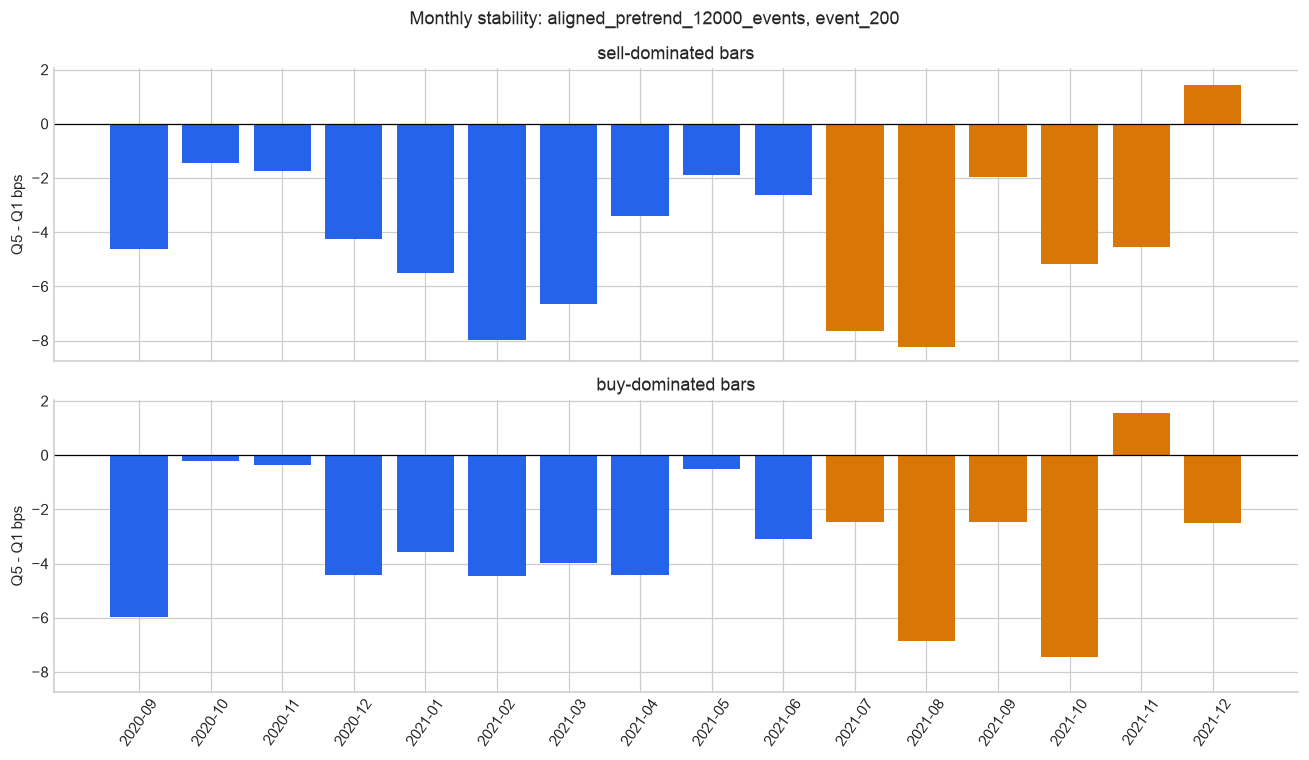

In [10]:
monthly = (
    frame.filter(
        pl.col('period').is_in(['validation', 'later sandbox']) &
        pl.col('feature_quintile').is_in([1, 5]) &
        pl.col('aligned_future_return_bps').is_finite()
    )
    .group_by('month', 'period', 'side', 'feature_quintile')
    .agg(pl.col('aligned_future_return_bps').mean().alias('mean_return'))
    .pivot(index=['month', 'period', 'side'], on='feature_quintile', values='mean_return')
    .drop_nulls(['1', '5'])
    .with_columns((pl.col('5') - pl.col('1')).alias('q5_minus_q1_bps'))
    .sort('month')
)
display(monthly)

fig, axes = plt.subplots(2, 1, figsize=(12, 7), sharex=True, sharey=True)
for ax, (side_value, side_label) in zip(axes, [(-1, 'sell'), (1, 'buy')]):
    part = monthly.filter(pl.col('side') == side_value)
    colours = [PERIOD_COLOURS[p] for p in part['period'].to_list()]
    ax.bar(part['month'].to_list(), part['q5_minus_q1_bps'].to_numpy(), color=colours)
    ax.axhline(0, color='black', lw=.8)
    ax.set_ylabel('Q5 - Q1 bps')
    ax.set_title(f'{side_label}-dominated bars')
axes[1].tick_params(axis='x', rotation=55)
fig.suptitle(f'Monthly stability: {FEATURE}, event_{BAR_SIZE}')
plt.tight_layout()
plt.show()

## Two-feature diagnostic, not a selected strategy

This heatmap shows whether the selected relationship is merely a proxy for another feature. Both axes use training-frozen quintiles. It is exploratory and must not be used to keep trying conditions until the result looks attractive.

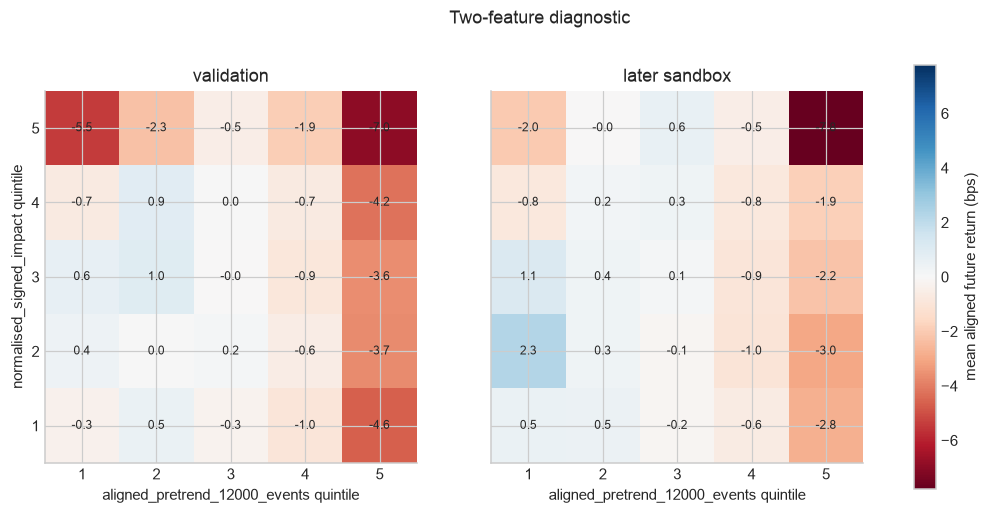

In [11]:
second_values = frame[SECOND_FEATURE].to_numpy()
second_train = second_values[
    (period_values == 'train') & (side == HEATMAP_SIDE) & np.isfinite(second_values)
]
second_cuts = np.quantile(second_train, [.2, .4, .6, .8])
second_q = np.zeros(frame.height, dtype=np.int8)
chosen = (side == HEATMAP_SIDE) & np.isfinite(second_values)
second_q[chosen] = np.digitize(second_values[chosen], second_cuts, right=True) + 1
heat = frame.with_columns(pl.Series('second_quintile', second_q))

matrices = []
for period in ['validation', 'later sandbox']:
    table = (
        heat.filter(
            (pl.col('period') == period) & (pl.col('side') == HEATMAP_SIDE) &
            (pl.col('feature_quintile') > 0) & (pl.col('second_quintile') > 0) &
            pl.col('aligned_future_return_bps').is_finite()
        )
        .group_by('feature_quintile', 'second_quintile')
        .agg(pl.col('aligned_future_return_bps').mean().alias('mean_return'))
    )
    matrix = np.full((5, 5), np.nan)
    for row in table.iter_rows(named=True):
        matrix[row['second_quintile'] - 1, row['feature_quintile'] - 1] = row['mean_return']
    matrices.append(matrix)

limit = max(float(np.nanmax(np.abs(matrix))) for matrix in matrices)
fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharex=True, sharey=True)
for ax, period, matrix in zip(axes, ['validation', 'later sandbox'], matrices):
    image = ax.imshow(matrix, origin='lower', cmap='RdBu', vmin=-limit, vmax=limit)
    for j in range(5):
        for i in range(5):
            ax.text(i, j, f'{matrix[j, i]:.1f}', ha='center', va='center', fontsize=8)
    ax.set_title(period)
    ax.set_xlabel(f'{FEATURE} quintile')
    ax.set_xticks(range(5), range(1, 6))
    ax.set_yticks(range(5), range(1, 6))
axes[0].set_ylabel(f'{SECOND_FEATURE} quintile')
fig.colorbar(image, ax=axes, label='mean aligned future return (bps)')
fig.suptitle('Two-feature diagnostic')
plt.show()

## Interpretation before profitability modelling

- A negative Q5-minus-Q1 spread means relative mean reversion, but it does not by itself specify whether to trade Q5, Q1 or both.
- The full quintile and smooth-bin curves should be monotonic enough to support a simple frozen threshold.
- Month charts reveal whether the aggregate result comes from a few episodes.
- Agreement across 200/500/1,000-event bars is robustness, not three independent discoveries.
- The next stage should choose one entry rule, one exit rule and a policy for overlapping signals before applying fees, spread, slippage and position limits.
- Market-state conditioning should follow the unconditional strategy definition. A small number of states can then be tested as prespecified interactions rather than used to rescue a weak rule.
- Mutual information should later use training-only estimators and block or circular-shift nulls; the single random shuffle used in the early notebook is too optimistic for serial data.